In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

XGBoost versao: 3.3.0

Shape original: (81881, 84)
Novas features de engenharia criadas com base nos insights de negocio.

Clusters criados com sucesso (K=6)
Removendo variaveis sujas/leakage: ['score_propensao_churn', 'cluster_sugerido_crm', 'data_primeira_apolice', 'data_nascimento', 'renovacoes_consecutivas']
Shape apos limpeza: (81881, 83)

Restricoes monotonicas aplicadas a: {'desconto_aplicado_pct': 1, 'satisfacao_nps': -1, 'num_reclamacoes_12m': 1, 'tempo_medio_resposta_dias': 1, 'tempo_resolucao_ultimo_sinistro': 1, 'num_produtos_contratados': -1, 'pagamento_em_dia': -1, 'score_engajamento_digital': -1, 'ultimo_login_portal_dias': 1, 'atrito_atendimento': 1, 'dias_login_por_engajamento': 1, 'barreira_saida': -1}
TREINAMENTO XGBOOST OTIMIZADO (5-FOLD CV)
Fold 1 | Melhor Arvore:  125 | AUC: 0.8377
Fold 2 | Melhor Arvore:  323 | AUC: 0.8308
Fold 3 | Melhor Arvore:  301 | AUC: 0.8426
Fold 4 | Melhor Arvore:  165 | AUC: 0.8265
Fold 5 | Melhor Arvore:  367 | AUC: 0.8257

AUC Medio de

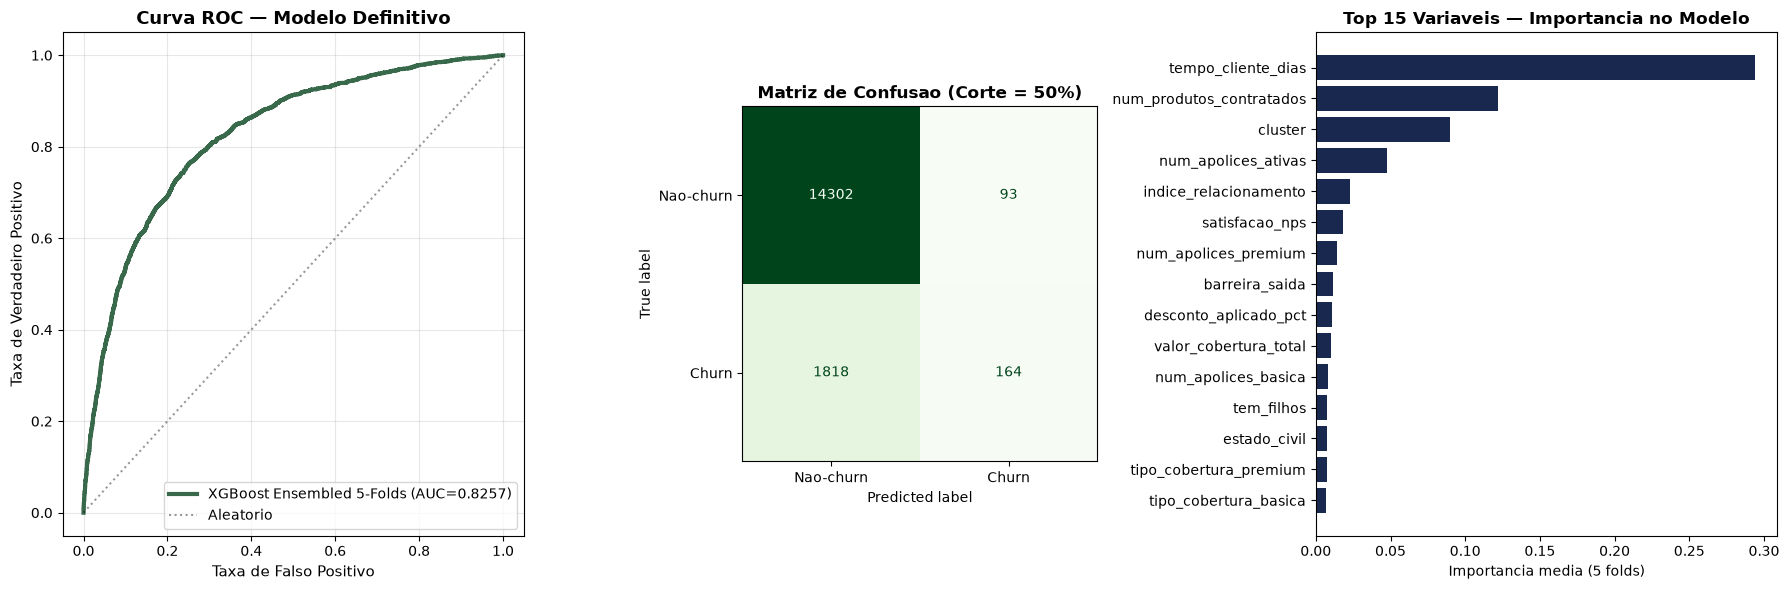

In [4]:
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, precision_recall_curve, average_precision_score
)
 
import xgboost as xgb
 
# ==========================================
# 1. CONFIGURACOES VISUAIS E VARIAVEIS
# ==========================================
PRT_NAVY  = "#19284F"
PRT_GREEN = "#39694B"
PRT_GRAY  = "#737C8A"
RANDOM_STATE = 42
 
print(f"XGBoost versao: {xgb.__version__}\n")
 
# ==========================================
# 2. CARREGAMENTO
# ==========================================
df = pd.read_csv("../bases/tabelas_unificadas/Base_Unificada_Tratada.csv")
print(f"Shape original: {df.shape}")
 
# ------------------------------------------
# 2.1 CORRECAO DEFENSIVA DE TIPOS
# Se pagamento_em_dia ainda estiver como string (ex: "Sim"/"Nao"),
# convertemos para binario. O insight de negocio diz que a AUSENCIA de
# pagamento em dia e o primeiro sinal de churn involuntario, entao
# precisamos garantir que o modelo receba isso como numero (1 = em dia).
# ------------------------------------------
if "pagamento_em_dia" in df.columns and df["pagamento_em_dia"].dtype == object:
    mapa_pagamento = {"Sim": 1, "Em dia": 1, "sim": 1, "Nao": 0, "Não": 0, "nao": 0}
    df["pagamento_em_dia"] = df["pagamento_em_dia"].map(mapa_pagamento)
    print("pagamento_em_dia convertido para binario.")
 
# ==========================================
# 3. FEATURE ENGINEERING A PARTIR DOS INSIGHTS
# ==========================================
# Cada feature abaixo traduz um insight de negocio em um sinal explicito
# para o modelo. O XGBoost consegue aprender interacoes sozinho, mas
# oferecer esses sinais prontos acelera o aprendizado e deixa a
# feature_importances_ final mais facil de validar contra a EDA.
 
# --- Insight (Engajamento e Marketing): baixo score_engajamento_digital
# + alto ultimo_login_portal_dias = cliente "descolado" da seguradora.
if {"score_engajamento_digital", "ultimo_login_portal_dias"}.issubset(df.columns):
    df["dias_login_por_engajamento"] = (
        df["ultimo_login_portal_dias"] / (df["score_engajamento_digital"] + 1)
    )
 
# --- Insight (Atendimento e Sinistros): reclamacoes + tempo de resposta
# + tempo de resolucao do ultimo sinistro = fricção de atendimento,
# que reduz o NPS e aumenta o churn.
cols_atrito = ["num_reclamacoes_12m", "tempo_medio_resposta_dias", "tempo_resolucao_ultimo_sinistro"]
cols_atrito_presentes = [c for c in cols_atrito if c in df.columns]
if cols_atrito_presentes:
    imp_atrito = SimpleImputer(strategy="median")
    atrito_scaled = StandardScaler().fit_transform(imp_atrito.fit_transform(df[cols_atrito_presentes]))
    df["atrito_atendimento"] = atrito_scaled.mean(axis=1)
 
# --- Insight (Contratos): sensibilidade a preco proporcional a renda,
# nao apenas o valor absoluto do premio.
if {"valor_premio_anual", "renda_anual"}.issubset(df.columns):
    df["premio_sobre_renda"] = df["valor_premio_anual"] / (df["renda_anual"] + 1)
 
# --- Insight (Contratos): quanto mais produtos contratados, maior a
# barreira de saida (burocratica e de apolices ativas).
if {"num_produtos_contratados", "num_apolices_ativas"}.issubset(df.columns):
    df["barreira_saida"] = df["num_produtos_contratados"] * df["num_apolices_ativas"]
 
print("Novas features de engenharia criadas com base nos insights de negocio.")
 
# ==========================================
# 4. CRIACAO DE CLUSTERS
# ==========================================
FEATURES_CLUSTER = [
    "tempo_cliente_dias", "num_apolices_ativas", "num_produtos_contratados",
    "desconto_aplicado_pct", "indice_relacionamento", "num_apolices_basica",
    "satisfacao_nps", "tipo_cobertura_basica", "estado_civil", "tipo_cobertura_premium",
    "tem_filhos", "renda_anual", "qtd_dependentes", "valor_imovel",
    "num_apolices_premium", "valor_cobertura_total", "idade", "num_apolices_padrao",
    "score_engajamento_digital", "pagamento_em_dia", "num_reclamacoes_12m",
    "num_acessos_app_mes", "possui_imovel", "tipo_cobertura_padrao",
    "valor_premio_anual", "franquia_media"
]
 
K_FINAL = 6
 
X_c = df[FEATURES_CLUSTER].copy()
imp_c = SimpleImputer(strategy="median")
X_c_scaled = StandardScaler().fit_transform(imp_c.fit_transform(X_c))
 
kmeans = KMeans(n_clusters=K_FINAL, random_state=RANDOM_STATE, n_init=10)
df["cluster"] = kmeans.fit_predict(X_c_scaled)
 
print(f"\nClusters criados com sucesso (K={K_FINAL})")
 
# ==========================================
# 5. LIMPEZA DE LEAKAGE E MULTICOLINEARIDADE
# ==========================================
# score_propensao_churn e cluster_sugerido_crm sao removidos por instrucao
# explicita: foram feitos por outra empresa e nao devem alimentar o modelo.
colunas_remover = ["score_propensao_churn", "cluster_sugerido_crm",
                   "data_primeira_apolice", "data_nascimento", "renovacoes_consecutivas"]
 
presentes = [c for c in colunas_remover if c in df.columns]
if presentes:
    df = df.drop(columns=presentes)
    print(f"Removendo variaveis sujas/leakage: {presentes}")
 
# NOTA: renovacoes_consecutivas foi removida do dataset original por
# multicolinearidade com tempo_cliente_dias (corr=0.94 na matriz de
# correlacao). Se voce quiser usa-la em vez de tempo_cliente_dias, troque
# a variavel removida e ajuste a lista MONOTONE_MAP abaixo de acordo.
 
target = "churned"
X = df.drop(columns=[target])
y = df[target]
 
print(f"Shape apos limpeza: {X.shape}\n")
 
imputer_final = SimpleImputer(strategy="median")
X_imp = pd.DataFrame(imputer_final.fit_transform(X), columns=X.columns)
 
# ==========================================
# 6. SPLIT LOCAL (80% TREINO / 20% TESTE)
# ==========================================
X_train, X_test, y_train, y_test = train_test_split(
    X_imp, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
 
# ==========================================
# 7. RESTRICOES MONOTONICAS BASEADAS NOS INSIGHTS
# ==========================================
# +1  = a variavel so pode AUMENTAR a probabilidade de churn conforme cresce
# -1  = a variavel so pode DIMINUIR a probabilidade de churn conforme cresce
#  0  = sem restricao (deixamos o modelo livre para aprender a relacao)
#
# So aplicamos restricao onde a EDA e os insights de negocio confirmam uma
# direcao clara. Variaveis com efeito ambiguo (ex: valor_premio_anual,
# estado_civil) ficam sem restricao para nao enviesar o modelo.
MONOTONE_MAP = {
    "desconto_aplicado_pct": 1,        # mais desconto -> mais churn (estrategia ineficaz, confirmado na EDA)
    "satisfacao_nps": -1,              # mais satisfacao -> menos churn
    "num_reclamacoes_12m": 1,          # mais reclamacoes -> mais churn
    "tempo_medio_resposta_dias": 1,    # atendimento mais lento -> mais churn
    "tempo_resolucao_ultimo_sinistro": 1,  # sinistro demorado -> mais churn
    "num_produtos_contratados": -1,    # mais produtos -> mais barreira de saida -> menos churn
    "pagamento_em_dia": -1,            # em dia (1) -> menos churn
    "score_engajamento_digital": -1,   # mais engajamento -> menos churn
    "ultimo_login_portal_dias": 1,     # mais tempo sem logar -> mais churn
    "atrito_atendimento": 1,           # feature nova: mais fricção -> mais churn
    "dias_login_por_engajamento": 1,   # feature nova: mais "descolado" -> mais churn
    "barreira_saida": -1,              # feature nova: mais barreira -> menos churn
}
 
monotone_constraints = tuple(MONOTONE_MAP.get(col, 0) for col in X_train.columns)
print("Restricoes monotonicas aplicadas a:", {k: v for k, v in MONOTONE_MAP.items() if k in X_train.columns})
 
# ==========================================
# 8. A MAQUINA DE VENCER: STRATIFIED K-FOLD
# ==========================================
xgb_params = {
    "n_estimators": 5000,
    "max_depth": 5,
    "learning_rate": 0.01,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "scale_pos_weight": 1.0,
    "tree_method": "hist",
    "eval_metric": "auc",
    "early_stopping_rounds": 50,
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
    "monotone_constraints": monotone_constraints,
}
 
N_FOLDS = 5
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
 
oof_preds = np.zeros(len(X_train))
test_preds = np.zeros(len(X_test))
modelos_treinados = []
 
print(f"{'='*55}")
print(f"TREINAMENTO XGBOOST OTIMIZADO ({N_FOLDS}-FOLD CV)")
print(f"{'='*55}")
 
for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
    X_f_train, y_f_train = X_train.iloc[train_idx], y_train.iloc[train_idx]
    X_f_val, y_f_val = X_train.iloc[val_idx], y_train.iloc[val_idx]
 
    clf = xgb.XGBClassifier(**xgb_params)
 
    clf.fit(
        X_f_train, y_f_train,
        eval_set=[(X_f_val, y_f_val)],
        verbose=False
    )
 
    y_val_proba = clf.predict_proba(X_f_val)[:, 1]
    oof_preds[val_idx] = y_val_proba
 
    test_preds += clf.predict_proba(X_test)[:, 1] / N_FOLDS
 
    modelos_treinados.append(clf)
 
    fold_auc = roc_auc_score(y_f_val, y_val_proba)
    print(f"Fold {fold+1} | Melhor Arvore: {clf.best_iteration:4d} | AUC: {fold_auc:.4f}")
 
auc_treino_cv = roc_auc_score(y_train, oof_preds)
print(f"\nAUC Medio de Validacao (OOF): {auc_treino_cv:.4f}")
 
# ==========================================
# 9. AVALIACAO NA BASE DE TESTE LOCAL (20%)
# ==========================================
auc_teste = roc_auc_score(y_test, test_preds)
avg_precision = average_precision_score(y_test, test_preds)
 
y_pred_binario = (test_preds >= 0.5).astype(int)
 
print(f"\n{'='*55}")
print("RESULTADO FINAL NA BASE DE TESTE (SIMULACAO KAGGLE)")
print(f"{'='*55}")
print(f"ROC-AUC Final      : {auc_teste:.4f}")
print(f"Avg Precision      : {avg_precision:.4f}")
print("\nRelatorio de Classificacao:")
print(classification_report(y_test, y_pred_binario, target_names=["Nao-churn", "Churn"]))
 
# ==========================================
# 10. IMPORTANCIA DE FEATURES x INSIGHTS DE NEGOCIO
# ==========================================
importancias = np.mean([m.feature_importances_ for m in modelos_treinados], axis=0)
df_importancia = pd.Series(importancias, index=X_train.columns).sort_values(ascending=False)
 
print("\nTop 15 variaveis mais usadas pelo modelo (media dos 5 folds):")
print(df_importancia.head(15))
 
# ==========================================
# 11. VISUALIZACAO DOS RESULTADOS
# ==========================================
fig = plt.figure(figsize=(18, 6))
gs = GridSpec(1, 3, width_ratios=[1.3, 1, 1.3])
 
# --- Grafico 1: Curva ROC ---
ax0 = fig.add_subplot(gs[0])
fpr, tpr, _ = roc_curve(y_test, test_preds)
ax0.plot(fpr, tpr, label=f"XGBoost Ensembled 5-Folds (AUC={auc_teste:.4f})", linewidth=3, color=PRT_GREEN)
ax0.plot([0, 1], [0, 1], linestyle=":", color="black", alpha=0.4, label="Aleatorio")
ax0.set_xlabel("Taxa de Falso Positivo", fontsize=11)
ax0.set_ylabel("Taxa de Verdadeiro Positivo", fontsize=11)
ax0.set_title("Curva ROC — Modelo Definitivo", fontsize=13, fontweight="bold")
ax0.legend(loc="lower right", fontsize=10)
ax0.grid(True, alpha=0.3)
 
# --- Grafico 2: Matriz de Confusao ---
ax1 = fig.add_subplot(gs[1])
cm = confusion_matrix(y_test, y_pred_binario)
disp = ConfusionMatrixDisplay(cm, display_labels=["Nao-churn", "Churn"])
disp.plot(ax=ax1, cmap="Greens", colorbar=False)
ax1.set_title("Matriz de Confusao (Corte = 50%)", fontsize=12, fontweight="bold")
 
# --- Grafico 3: Top 15 Feature Importances ---
ax2 = fig.add_subplot(gs[2])
top15 = df_importancia.head(15).sort_values()
ax2.barh(top15.index, top15.values, color=PRT_NAVY)
ax2.set_title("Top 15 Variaveis — Importancia no Modelo", fontsize=12, fontweight="bold")
ax2.set_xlabel("Importancia media (5 folds)", fontsize=10)
 
plt.tight_layout()
plt.show()


In [5]:
import pandas as pd
import numpy as np

print("Gerando o arquivo de submissão oficial para o Kaggle...")

# 1. Carrega a base oficial de teste do Kaggle (a base cega, sem as respostas de churn)
df_teste_real = pd.read_csv('../bases/bases_kaggle/Base_Unificada_Kaggle_Outer.csv') 

# 2. Captura os IDs originais correspondentes ao 'id_cliente' para montar o arquivo final
# Se na sua base o nome for diferente, ajuste entre as aspas
coluna_id_orig = 'id_cliente' if 'id_cliente' in df_teste_real.columns else df_teste_real.columns[0]
ids_clientes = df_teste_real[coluna_id_orig].copy()

# =========================================================================
# NOTA: Lembre-se de rodar aqui as suas funções de limpeza e padronização 
# na tabela 'df_teste_real' para que ela fique com as mesmas colunas do treino!
# Exemplo: df_teste_tratado = limpar_tabela_marketing(df_teste_real)
# =========================================================================

# 3. Garante que a ordem e o nome de todas as colunas sejam idênticos ao X_train
# Isso evita o erro de colunas faltantes ou fora de ordem no XGBoost
df_teste_pronto = df_teste_real.reindex(columns=X_train.columns, fill_value=0)

# 4. Faz a predição combinada tirando a média das probabilidades dos 5 modelos
probabilidades_finais = np.zeros(len(df_teste_pronto))

for modelo in modelos_treinados:
    probabilidades_finais += modelo.predict_proba(df_teste_pronto)[:, 1] / len(modelos_treinados)

# 5. Monta o DataFrame estruturado no padrão exato exigido pelo desafio
submissao_kaggle = pd.DataFrame({
    'Id': ids_clientes,
    'churn_prob': probabilidades_finais
})

# 6. Salva o arquivo final em formato CSV
# O parâmetro index=False é OBRIGATÓRIO para o Pandas não criar uma coluna de numeração extra
submissao_kaggle.to_csv('submissao_final_xgboost.csv', index=False)

print("\n✅ Arquivo 'submissao_final_xgboost.csv' gerado com sucesso!")
print("\nPrimeiras linhas do arquivo para validação visual:")
print(submissao_kaggle.head())

Gerando o arquivo de submissão oficial para o Kaggle...

✅ Arquivo 'submissao_final_xgboost.csv' gerado com sucesso!

Primeiras linhas do arquivo para validação visual:
             Id  churn_prob
0  221300000002    0.038118
1  221300000020    0.090072
2  221300000097    0.071510
3  221300000148    0.107900
4  221300000166    0.084341


XGBoost versao: 3.3.0

Shape original: (81881, 84)
Removendo variaveis sujas/leakage: ['score_propensao_churn', 'cluster_sugerido_crm', 'data_primeira_apolice', 'data_nascimento', 'renovacoes_consecutivas']
Treino: (65504, 81) | Teste local: (16377, 81)

Clusters aplicados (fit apenas no treino, K=6)
TREINAMENTO XGBOOST (5-FOLD CV) — pipeline sem leakage
Fold 1 | Melhor Arvore:  290 | AUC: 0.8379
Fold 2 | Melhor Arvore:   77 | AUC: 0.8310
Fold 3 | Melhor Arvore:  403 | AUC: 0.8429
Fold 4 | Melhor Arvore:   14 | AUC: 0.8270
Fold 5 | Melhor Arvore:  521 | AUC: 0.8249

AUC Medio de Validacao (OOF): 0.8161

RESULTADO NO TESTE LOCAL (sem leakage no pipeline)
ROC-AUC Final : 0.8267
Avg Precision : 0.4265

Relatorio de Classificacao:
              precision    recall  f1-score   support

   Nao-churn       0.88      1.00      0.94     14395
       Churn       0.83      0.01      0.02      1982

    accuracy                           0.88     16377
   macro avg       0.86      0.51      0.48  

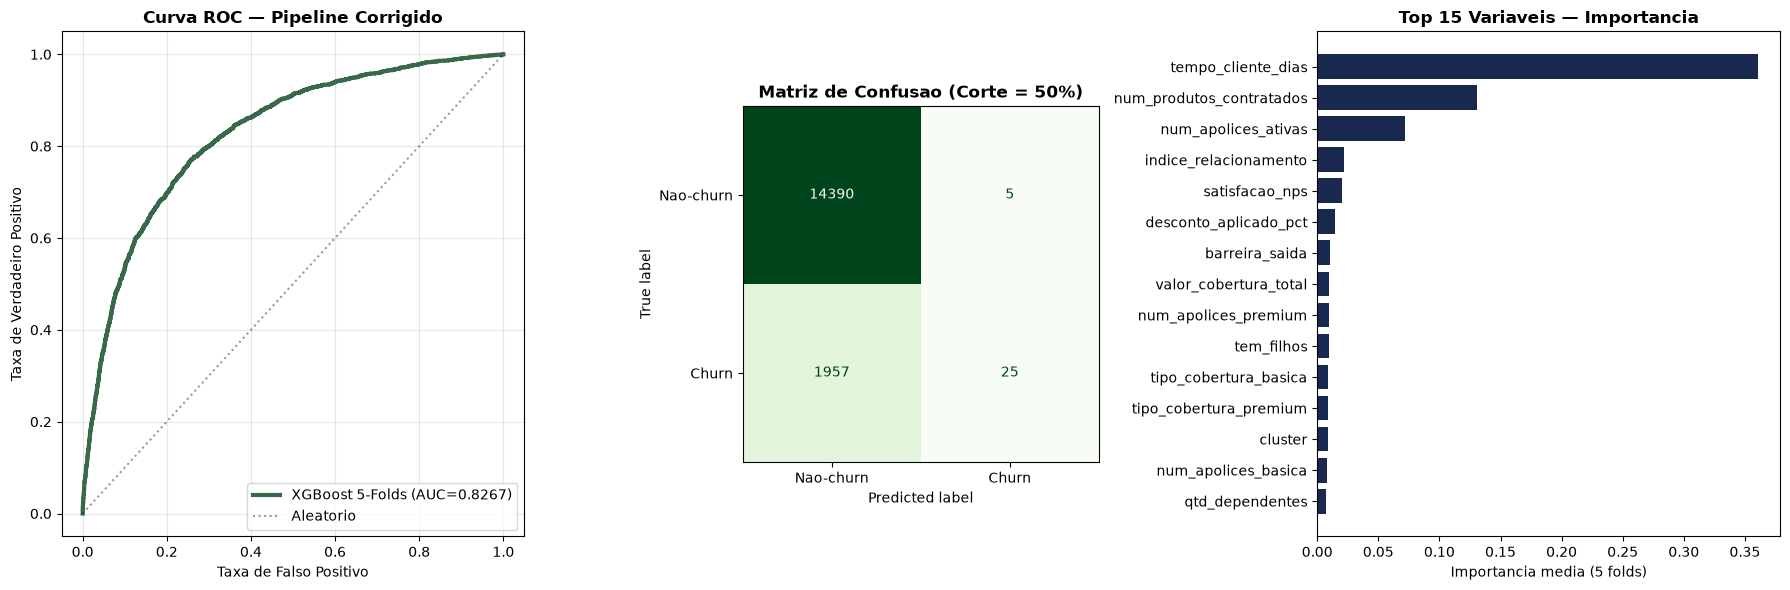

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, average_precision_score
)

import xgboost as xgb

# ==========================================
# 1. CONFIGURACOES
# ==========================================
PRT_NAVY  = "#19284F"
PRT_GREEN = "#39694B"
RANDOM_STATE = 42

print(f"XGBoost versao: {xgb.__version__}\n")

# ==========================================
# 2. CARREGAMENTO
# ==========================================
df = pd.read_csv("../bases/tabelas_unificadas/Base_Unificada_Tratada.csv")
print(f"Shape original: {df.shape}")

if "pagamento_em_dia" in df.columns and df["pagamento_em_dia"].dtype == object:
    mapa_pagamento = {"Sim": 1, "Em dia": 1, "sim": 1, "Nao": 0, "Não": 0, "nao": 0}
    df["pagamento_em_dia"] = df["pagamento_em_dia"].map(mapa_pagamento)

# ==========================================
# 3. FEATURE ENGINEERING (row-wise, sem leakage)
# ==========================================
# Essas contas sao feitas linha a linha, sem "aprender" nada da base
# inteira, entao podem ficar antes do split sem problema.
if {"score_engajamento_digital", "ultimo_login_portal_dias"}.issubset(df.columns):
    df["dias_login_por_engajamento"] = (
        df["ultimo_login_portal_dias"] / (df["score_engajamento_digital"] + 1)
    )

if {"valor_premio_anual", "renda_anual"}.issubset(df.columns):
    df["premio_sobre_renda"] = df["valor_premio_anual"] / (df["renda_anual"] + 1)

if {"num_produtos_contratados", "num_apolices_ativas"}.issubset(df.columns):
    df["barreira_saida"] = df["num_produtos_contratados"] * df["num_apolices_ativas"]

# ==========================================
# 4. LIMPEZA DE LEAKAGE CONHECIDO
# ==========================================
colunas_remover = ["score_propensao_churn", "cluster_sugerido_crm",
                   "data_primeira_apolice", "data_nascimento", "renovacoes_consecutivas"]
presentes = [c for c in colunas_remover if c in df.columns]
if presentes:
    df = df.drop(columns=presentes)
    print(f"Removendo variaveis sujas/leakage: {presentes}")

target = "churned"
X_raw = df.drop(columns=[target])
y = df[target]

# ==========================================
# 5. SPLIT *ANTES* DE QUALQUER FIT
# ==========================================
# Este e o ponto que provavelmente causou o gap entre validacao local
# (0.8257) e Kaggle (~0.73): imputer/scaler/kmeans eram ajustados no df
# inteiro antes do split, entao o "teste local" ja tinha vazado
# informacao para esses objetos. Agora dividimos primeiro e so
# ajustamos (fit) no treino.
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print(f"Treino: {X_train_raw.shape} | Teste local: {X_test_raw.shape}")

# ==========================================
# 6. CLUSTER — fit SOMENTE no treino
# ==========================================
FEATURES_CLUSTER = [
    "tempo_cliente_dias", "num_apolices_ativas", "num_produtos_contratados",
    "desconto_aplicado_pct", "indice_relacionamento", "num_apolices_basica",
    "satisfacao_nps", "tipo_cobertura_basica", "estado_civil", "tipo_cobertura_premium",
    "tem_filhos", "renda_anual", "qtd_dependentes", "valor_imovel",
    "num_apolices_premium", "valor_cobertura_total", "idade", "num_apolices_padrao",
    "score_engajamento_digital", "pagamento_em_dia", "num_reclamacoes_12m",
    "num_acessos_app_mes", "possui_imovel", "tipo_cobertura_padrao",
    "valor_premio_anual", "franquia_media"
]
FEATURES_CLUSTER = [c for c in FEATURES_CLUSTER if c in X_train_raw.columns]

K_FINAL = 6
imp_c = SimpleImputer(strategy="median").fit(X_train_raw[FEATURES_CLUSTER])
scaler_c = StandardScaler().fit(imp_c.transform(X_train_raw[FEATURES_CLUSTER]))
kmeans = KMeans(n_clusters=K_FINAL, random_state=RANDOM_STATE, n_init=10)
kmeans.fit(scaler_c.transform(imp_c.transform(X_train_raw[FEATURES_CLUSTER])))

def aplicar_cluster(X_part):
    X_part = X_part.copy()
    scaled = scaler_c.transform(imp_c.transform(X_part[FEATURES_CLUSTER]))
    X_part["cluster"] = kmeans.predict(scaled)
    return X_part

X_train_raw = aplicar_cluster(X_train_raw)
X_test_raw = aplicar_cluster(X_test_raw)
print(f"\nClusters aplicados (fit apenas no treino, K={K_FINAL})")

# ==========================================
# 7. IMPUTACAO FINAL — fit SOMENTE no treino
# ==========================================
imputer_final = SimpleImputer(strategy="median").fit(X_train_raw)
X_train = pd.DataFrame(imputer_final.transform(X_train_raw), columns=X_train_raw.columns)
X_test = pd.DataFrame(imputer_final.transform(X_test_raw), columns=X_test_raw.columns)

# GUARDE imp_c, scaler_c, kmeans e imputer_final (ex: pickle/joblib).
# Para gerar a submissao do Kaggle, aplique a MESMA sequencia
# (aplicar_cluster -> imputer_final.transform) no test.csv oficial,
# nunca fit_transform nele.

df_kaggle_test = pd.read_csv("../bases/bases_kaggle/Base_Unificada_Kaggle_Outer.csv")  # ajuste o caminho real
print(df_kaggle_test.shape)
print(df_kaggle_test.columns.tolist())

if "pagamento_em_dia" in df_kaggle_test.columns and df_kaggle_test["pagamento_em_dia"].dtype == object:
    df_kaggle_test["pagamento_em_dia"] = df_kaggle_test["pagamento_em_dia"].map(mapa_pagamento)

if {"score_engajamento_digital", "ultimo_login_portal_dias"}.issubset(df_kaggle_test.columns):
    df_kaggle_test["dias_login_por_engajamento"] = (
        df_kaggle_test["ultimo_login_portal_dias"] / (df_kaggle_test["score_engajamento_digital"] + 1)
    )

if {"valor_premio_anual", "renda_anual"}.issubset(df_kaggle_test.columns):
    df_kaggle_test["premio_sobre_renda"] = df_kaggle_test["valor_premio_anual"] / (df_kaggle_test["renda_anual"] + 1)

if {"num_produtos_contratados", "num_apolices_ativas"}.issubset(df_kaggle_test.columns):
    df_kaggle_test["barreira_saida"] = df_kaggle_test["num_produtos_contratados"] * df_kaggle_test["num_apolices_ativas"]

# guarde o ID antes de transformar, para a submissao final
id_kaggle = df_kaggle_test["cod_individuo"]  # ou o nome real da coluna de ID

df_kaggle_test = aplicar_cluster(df_kaggle_test)   # usa imp_c, scaler_c, kmeans do treino
X_kaggle_test = pd.DataFrame(
    imputer_final.transform(df_kaggle_test[X_train.columns]),
    columns=X_train.columns
)

# ==========================================
# 8. VALIDACAO ADVERSARIAL (opcional, mas recomendado)
# ==========================================
# Ajuda a checar se train e o test.csv do Kaggle vem de distribuicoes
# diferentes. Se o AUC aqui ficar bem acima de 0.5 (ex: >0.65-0.70),
# ha mudanca de distribuicao real entre as bases que merece investigacao
# antes de qualquer tuning de hiperparametro.
def validacao_adversarial(X_local, X_kaggle_test):
    X_adv = pd.concat([X_local, X_kaggle_test], axis=0)
    y_adv = np.array([0] * len(X_local) + [1] * len(X_kaggle_test))
    Xa_tr, Xa_val, ya_tr, ya_val = train_test_split(
        X_adv, y_adv, test_size=0.3, stratify=y_adv, random_state=RANDOM_STATE
    )
    clf_adv = xgb.XGBClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        tree_method="hist", random_state=RANDOM_STATE
    )
    clf_adv.fit(Xa_tr, ya_tr)
    auc_adv = roc_auc_score(ya_val, clf_adv.predict_proba(Xa_val)[:, 1])
    print(f"AUC validacao adversarial (treino vs kaggle test): {auc_adv:.4f}")
    print("Proximo de 0.5 = distribuicoes parecidas. Bem acima = ha covariate shift.")
    return clf_adv, auc_adv

# Exemplo de uso (descomente e ajuste o caminho quando for rodar):
# df_kaggle_test = pd.read_csv("../bases/test.csv")
# df_kaggle_test = aplicar_cluster(df_kaggle_test)
# X_kaggle_test = pd.DataFrame(imputer_final.transform(df_kaggle_test[X_train.columns]),
#                               columns=X_train.columns)
# validacao_adversarial(X_train, X_kaggle_test)

# ==========================================
# 9. RESTRICOES MONOTONICAS BASEADAS NOS INSIGHTS
# ==========================================
MONOTONE_MAP = {
    "desconto_aplicado_pct": 1,
    "satisfacao_nps": -1,
    "num_reclamacoes_12m": 1,
    "tempo_medio_resposta_dias": 1,
    "tempo_resolucao_ultimo_sinistro": 1,
    "num_produtos_contratados": -1,
    "pagamento_em_dia": -1,
    "score_engajamento_digital": -1,
    "ultimo_login_portal_dias": 1,
    "dias_login_por_engajamento": 1,
    "barreira_saida": -1,
}
monotone_constraints = tuple(MONOTONE_MAP.get(col, 0) for col in X_train.columns)

# ==========================================
# 10. TREINAMENTO K-FOLD
# ==========================================
xgb_params = {
    "n_estimators": 5000,
    "max_depth": 5,
    "learning_rate": 0.01,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "scale_pos_weight": 1.0,
    "tree_method": "hist",
    "eval_metric": "auc",
    "early_stopping_rounds": 50,
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
    "monotone_constraints": monotone_constraints,
}

N_FOLDS = 5
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

oof_preds = np.zeros(len(X_train))
test_preds = np.zeros(len(X_test))
modelos_treinados = []

print(f"{'='*55}\nTREINAMENTO XGBOOST ({N_FOLDS}-FOLD CV) — pipeline sem leakage\n{'='*55}")

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
    X_f_train, y_f_train = X_train.iloc[train_idx], y_train.iloc[train_idx]
    X_f_val, y_f_val = X_train.iloc[val_idx], y_train.iloc[val_idx]

    clf = xgb.XGBClassifier(**xgb_params)
    clf.fit(X_f_train, y_f_train, eval_set=[(X_f_val, y_f_val)], verbose=False)

    y_val_proba = clf.predict_proba(X_f_val)[:, 1]
    oof_preds[val_idx] = y_val_proba
    test_preds += clf.predict_proba(X_test)[:, 1] / N_FOLDS
    modelos_treinados.append(clf)

    fold_auc = roc_auc_score(y_f_val, y_val_proba)
    print(f"Fold {fold+1} | Melhor Arvore: {clf.best_iteration:4d} | AUC: {fold_auc:.4f}")

auc_treino_cv = roc_auc_score(y_train, oof_preds)
print(f"\nAUC Medio de Validacao (OOF): {auc_treino_cv:.4f}")

# ==========================================
# 11. AVALIACAO NO TESTE LOCAL (agora sem leakage)
# ==========================================
auc_teste = roc_auc_score(y_test, test_preds)
avg_precision = average_precision_score(y_test, test_preds)
y_pred_binario = (test_preds >= 0.5).astype(int)

print(f"\n{'='*55}\nRESULTADO NO TESTE LOCAL (sem leakage no pipeline)\n{'='*55}")
print(f"ROC-AUC Final : {auc_teste:.4f}")
print(f"Avg Precision : {avg_precision:.4f}")
print("\nRelatorio de Classificacao:")
print(classification_report(y_test, y_pred_binario, target_names=["Nao-churn", "Churn"]))
print("\n>> Compare este AUC com o AUC do Kaggle. Se o gap encolher bastante,")
print(">> confirma que o leakage do pipeline antigo era o problema principal.")

# ==========================================
# 12. IMPORTANCIA DE FEATURES
# ==========================================
importancias = np.mean([m.feature_importances_ for m in modelos_treinados], axis=0)
df_importancia = pd.Series(importancias, index=X_train.columns).sort_values(ascending=False)
print("\nTop 15 variaveis mais usadas pelo modelo:")
print(df_importancia.head(15))

# ==========================================
# 13. VISUALIZACAO
# ==========================================
fig = plt.figure(figsize=(18, 6))
gs = GridSpec(1, 3, width_ratios=[1.3, 1, 1.3])

ax0 = fig.add_subplot(gs[0])
fpr, tpr, _ = roc_curve(y_test, test_preds)
ax0.plot(fpr, tpr, label=f"XGBoost 5-Folds (AUC={auc_teste:.4f})", linewidth=3, color=PRT_GREEN)
ax0.plot([0, 1], [0, 1], linestyle=":", color="black", alpha=0.4, label="Aleatorio")
ax0.set_xlabel("Taxa de Falso Positivo")
ax0.set_ylabel("Taxa de Verdadeiro Positivo")
ax0.set_title("Curva ROC — Pipeline Corrigido", fontweight="bold")
ax0.legend(loc="lower right", fontsize=10)
ax0.grid(True, alpha=0.3)

ax1 = fig.add_subplot(gs[1])
cm = confusion_matrix(y_test, y_pred_binario)
disp = ConfusionMatrixDisplay(cm, display_labels=["Nao-churn", "Churn"])
disp.plot(ax=ax1, cmap="Greens", colorbar=False)
ax1.set_title("Matriz de Confusao (Corte = 50%)", fontweight="bold")

ax2 = fig.add_subplot(gs[2])
top15 = df_importancia.head(15).sort_values()
ax2.barh(top15.index, top15.values, color=PRT_NAVY)
ax2.set_title("Top 15 Variaveis — Importancia", fontweight="bold")
ax2.set_xlabel("Importancia media (5 folds)")

plt.tight_layout()
plt.show()